In [1]:
import astropy.io.fits as pf
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
import math
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm
import os
import subprocess
import importlib as imp
import copy
import scipy.stats
from matplotlib.pyplot import cm
from scipy.stats import kde
import figure_subroutines as subs
from astropy import units as u
from astropy.coordinates import SkyCoord

In [3]:
mos_ST = fits.open('../../OB_Mosaics_K/MQ2/b/u/mq2bu_sst_image.fits')
mos_ST_hdr = mos_ST[0].header
mos_ST_data = mos_ST[0].data

lonST,latST = subs.make_axis_lists_2D(mos_ST_hdr)
print(lonST)
print(latST)

mos_SA = fits.open('../../GMIMS_CGPS_OB_RW/GMIMS_b/UB_GMIMS_RW.fits')
mos_SA_hdr = mos_SA[0].header
mos_SA_data = mos_SA[0].data

lonSA,latSA = subs.make_axis_lists_2D(mos_SA_hdr)
print(lonSA)
print(latSA)

mos_STSA = fits.open('../../GMIMS_CGPS_OB_RW/Mosaics/MQ2/b/u/mq2bu_CGPS_GMIMS_image.fits')
mos_STSA_hdr = mos_STSA[0].header
mos_STSA_data = mos_STSA[0].data

lonSTSA,latSTSA = subs.make_axis_lists_2D(mos_STSA_hdr)
print(lonSTSA)
print(latSTSA)

d2G = mos_SA_hdr['CDELT2']/2.
print(d2G)

d2 = mos_STSA_hdr['CDELT2']/2.
print(d2)

print(mos_SA_data.shape)

[71.30999949 71.30499949 71.29999949 ... 66.20500051 66.20000051
 66.19500051]
[0.44000051 0.44500051 0.45000051 ... 5.54499949 5.54999949 5.55499949]
[100.   99.5  99.   98.5  98.   97.5  97.   96.5  96.   95.5  95.   94.5
  94.   93.5  93.   92.5  92.   91.5  91.   90.5  90.   89.5  89.   88.5
  88.   87.5  87.   86.5  86.   85.5  85.   84.5  84.   83.5  83.   82.5
  82.   81.5  81.   80.5  80.   79.5  79.   78.5  78.   77.5  77.   76.5
  76.   75.5  75.   74.5  74.   73.5  73.   72.5  72.   71.5  71.   70.5
  70.   69.5  69.   68.5  68.   67.5  67.   66.5  66.   65.5  65.   64.5
  64.   63.5  63.   62.5  62.   61.5  61.   60.5  60.   59.5  59.   58.5
  58.   57.5  57.   56.5  56.   55.5  55.   54.5  54.   53.5  53.   52.5
  52.   51.5  51.   50.5  50.   49.5  49.   48.5  48.   47.5  47.   46.5
  46.   45.5  45.   44.5  44.   43.5  43.   42.5  42.   41.5  41.   40.5
  40.   39.5  39.   38.5  38.   37.5  37.   36.5  36.   35.5  35.   34.5
  34.   33.5  33.   32.5  32.   31.5  31.   30

[71.25, 66.75, 0.75, 5.25]
71.244999501
66.7500004
0.7550004490000002
5.24999955

[71.25, 66.75, 0.75, 5.25]
71.0
66.5
1.0
5.5


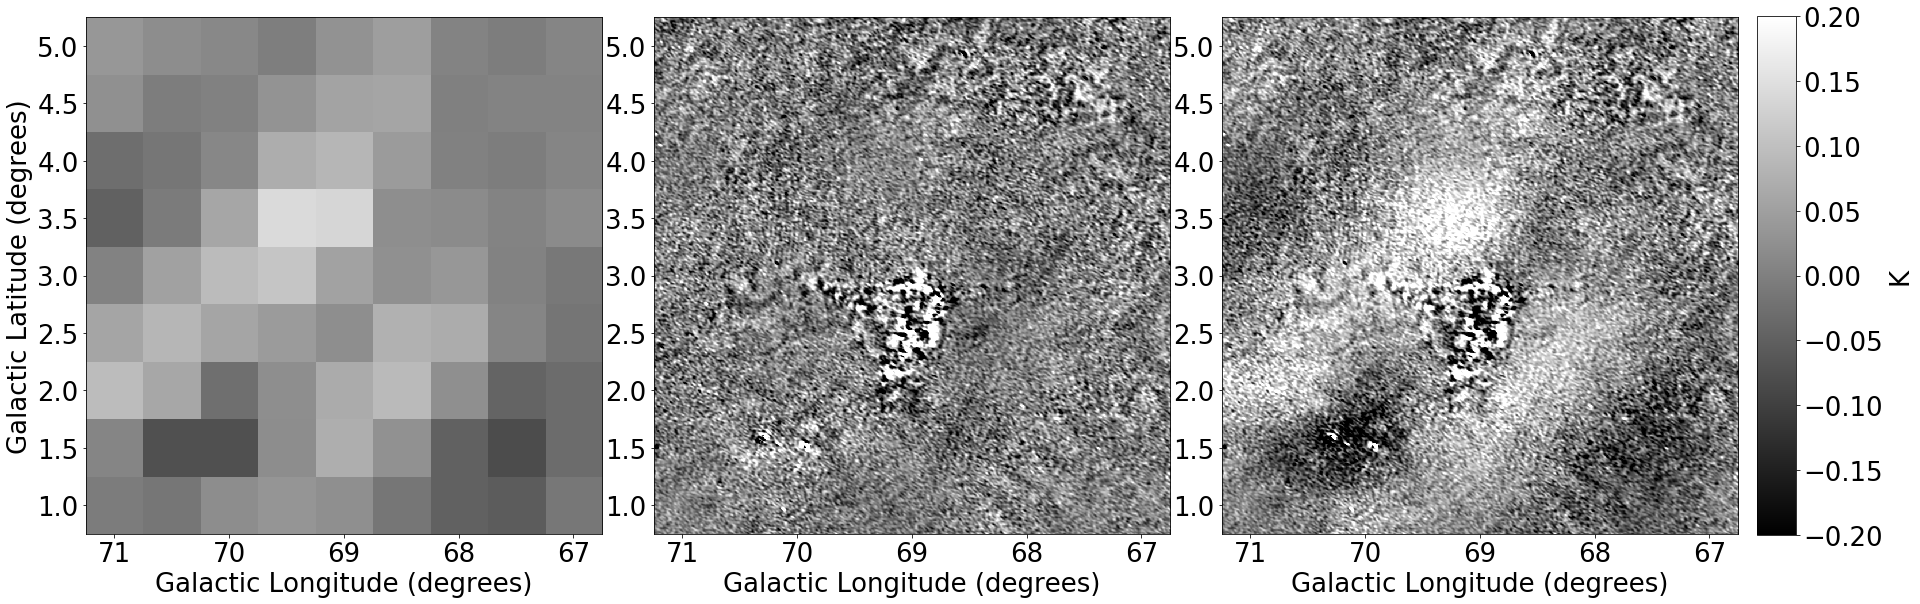

In [4]:
lmax = 71.
lmin = 67.
bmin = 1.
bmax = 5.

bottom = 0.05
top = 0.99
right = 0.9
left = 0.05
PImin = -0.2
PImax = 0.2
fs = 26

wx = np.where((lonST <= lmax+d2G-d2) & (lonST >= lmin-d2G+d2))
wy = np.where((latST <= bmax+d2G-d2) & (latST >= bmin-d2G+d2))
wxmin = np.min(wx)
wxmax = np.max(wx)+1
wymin = np.min(wy)
wymax = np.max(wy)+1
extent = [lmax+d2G,lmin-d2G,bmin-d2G,bmax+d2G]
print(extent)
print(lonST[wxmin])
print(lonST[wxmax])
print(latST[wymin])
print(latST[wymax])

print('')
wGx = np.where((lonSA <= lmax) & (lonSA >= lmin))
wGy = np.where((latSA <= bmax) & (latSA >= bmin))
wGxmin = np.min(wGx)
wGxmax = np.max(wGx)+1
wGymin = np.min(wGy)
wGymax = np.max(wGy)+1
extentG = [lmax+d2G,lmin-d2G,bmin-d2G,bmax+d2G]
print(extentG)
print(lonSA[wGxmin])
print(lonSA[wGxmax])
print(latSA[wGymin])
print(latSA[wGymax])

fig = plt.figure(figsize=(27,9))
plt.subplots_adjust(wspace=0.1,hspace=0.1)
plt.subplots_adjust(top = top, bottom = bottom, right = right, left = left)

ax1 = fig.add_subplot(131)
image1 = ax1.imshow(mos_SA_data[wGymin:wGymax,wGxmin:wGxmax],origin='lower',vmin=PImin,vmax=PImax,cmap='gray',
                   extent=extentG)
ax1.tick_params(axis="x", labelsize=fs)
ax1.tick_params(axis="y", labelsize=fs)
ax1.set_ylabel('Galactic Latitude (degrees)', fontsize=fs)
ax1.set_xlabel('Galactic Longitude (degrees)', fontsize=fs)

ax2 = fig.add_subplot(132)
image2 = ax2.imshow(mos_ST_data[0,0,wymin:wymax,wxmin:wxmax],origin='lower',vmin=PImin,vmax=PImax,cmap='gray',extent=extent)
ax2.tick_params(axis="x", labelsize=fs)
ax2.tick_params(axis="y", labelsize=fs)
ax2.set_xlabel('Galactic Longitude (degrees)', fontsize=fs)

ax3 = fig.add_subplot(133)
image3 = ax3.imshow(mos_STSA_data[0,0,wymin:wymax,wxmin:wxmax],origin='lower',vmin=PImin,vmax=PImax,cmap='gray',extent=extent)
ax3.tick_params(axis="x", labelsize=fs)
ax3.tick_params(axis="y", labelsize=fs)
ax3.set_xlabel('Galactic Longitude (degrees)', fontsize=fs)

cax = fig.add_axes([0.91,0.12,0.02,0.8])
cb = fig.colorbar(image3,orientation='vertical',cax=cax)  
cb.set_label(label='K',size=fs)
cb.ax.tick_params(labelsize=fs)

plt.savefig('FIGURES/UV_CGPS_GMIMS_combine_mq2.pdf')

In [93]:
weight_I = fits.open('../../OB_Mosaics_K/MOB5/StokesI/mob5_1420MHz_I_sst_wt.fits')
weight_I_hdr = weight_I[0].header
weight_I_data = weight_I[0].data

lonI,latI = subs.make_axis_lists_2D(weight_I_hdr)
print(lonI)
print(latI)

weight_PI = fits.open('../../OB_Mosaics_K/MOB5/a/q/mob5aq_sst_wt.fits')
weight_PI_hdr = weight_PI[0].header
weight_PI_data = weight_PI[0].data

lonPI,latPI = subs.make_axis_lists_2D(weight_PI_hdr)
print(lonPI)
print(latPI)

print(weight_I_data.shape)

[71.30999949 71.30499949 71.29999949 ... 66.20500051 66.20000051
 66.19500051]
[4.44000051 4.44500051 4.45000051 ... 9.54499949 9.54999949 9.55499949]
[71.30999949 71.30499949 71.29999949 ... 66.20500051 66.20000051
 66.19500051]
[4.44000051 4.44500051 4.45000051 ... 9.54499949 9.54999949 9.55499949]
(1, 1, 1024, 1024)


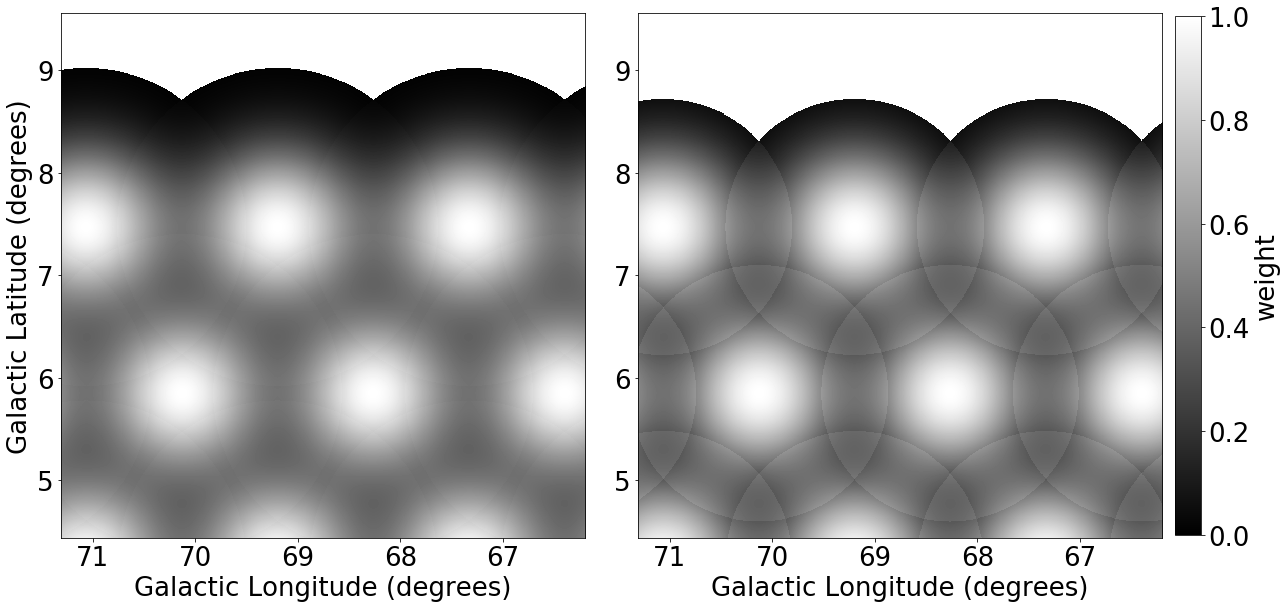

In [99]:
fig = plt.figure(figsize=(18,9))
plt.subplots_adjust(wspace=0.1,hspace=0.1)
plt.subplots_adjust(top = top, bottom = bottom, right = right, left = left)

extent=[lonI[0]+d2,lonI[-1]-d2,latI[0]-d2,latI[-1]+d2]

ax1 = fig.add_subplot(121)
image1 = ax1.imshow(weight_I_data[0,0,:,:],origin='lower',cmap='gray',extent=extent,vmin=0,vmax=1)
ax1.tick_params(axis="x", labelsize=fs)
ax1.tick_params(axis="y", labelsize=fs)
ax1.set_ylabel('Galactic Latitude (degrees)', fontsize=fs)
ax1.set_xlabel('Galactic Longitude (degrees)', fontsize=fs)

ax2 = fig.add_subplot(122)
image2 = ax2.imshow(weight_PI_data[0,0,:,:],origin='lower',cmap='gray',extent=extent,vmin=0,vmax=1)
ax2.tick_params(axis="x", labelsize=fs)
ax2.tick_params(axis="y", labelsize=fs)
ax2.set_xlabel('Galactic Longitude (degrees)', fontsize=fs)

cax = fig.add_axes([0.91,0.12,0.02,0.8])
cb = fig.colorbar(image2,orientation='vertical',cax=cax)  
cb.set_label(label='weight',size=fs)
cb.ax.tick_params(labelsize=fs)

plt.savefig('FIGURES/weightmaps.pdf')